# Module 3: Model Training — Walk-Forward Cross-Validation

This notebook trains the ranking model and generates **honest out-of-sample predictions** using walk-forward cross-validation.

**Two model configurations are compared:**
- **Basic** — XGBoost LambdaRanker on 24 hand-crafted features (momentum, volatility, trend, WQ alphas)
- **Alphaforge** — Same ranker extended with GP-evolved alpha signals and an LSTM-Attention meta-combiner (`DynamicAlphaCombiner`)

**Walk-forward setup:**
- 24-month initial training window
- 6-month rolling test windows
- 21-day gap between train and test end to prevent leakage

**Input:** `data/featured_data.parquet`  
**Output:** `honest_test_df_basic.parquet`, `honest_test_df_alphaforge.parquet` — OOS predictions used by notebook 04 for backtesting

## 3.1 Imports and Setup

In [2]:

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath('/kaggle/input/datasets/phmhuyphongp/modules-vn')
if project_root not in sys.path:
    sys.path.append(project_root)

import src.models as md
import src.evaluation as ev
import src.features as ft
from config import candidate_features, BASE_MODEL_PARAMS

## 3.2 Data Loading

In [3]:
DATA_PATH = '/kaggle/input/datasets/phmhuyphongp/vn-dataset/market_data.parquet'
df = pd.read_parquet(DATA_PATH)
df = ft.build_features(df)
df = ft.build_targets(df)
df = ft.target_generating_ranking(df)
print(f'Shape          : {df.shape}')
print(f'Date range     : {df["date"].min()} → {df["date"].max()}')
print(f'Unique tickers : {df["Symbol"].nunique()}')
df.head()

Generating WorldQuant Alphas...


Dropping 2 date(s) with fewer than 50 stocks after NaN removal.


Shape          : (609262, 72)
Date range     : 2017-01-05 00:00:00 → 2026-05-11 00:00:00
Unique tickers : 299


,date,open,high,low,close,volume,Symbol,log_ret_1w,log_ret_1m,log_ret_3m,...,WQ_Alpha_101,WQ_Alpha_103,WQ_Alpha_200,WQ_Alpha_201,WQ_Alpha_202,next_1m_ret,next_1w_ret,risk_adj_ret,target_quintile,qid
6459,2017-01-05,3.34,3.36,3.29,3.33,471881,ACB,0.094410,0.087831,0.074801,...,-1.246012,0.24,0.000300,1.290539,-0.187558,0.222543,0.121447,0.777367,4,0
19537,2017-01-05,2.09,2.13,2.08,2.13,61050,AGR,-0.108704,0.111226,0.044017,...,-0.210390,0.38,0.289357,-0.004146,-0.546832,0.365556,0.036871,0.816665,4,0
27780,2017-01-05,6.79,7.00,6.77,6.84,1407810,ASM,0.016382,-0.002950,-0.051810,...,-0.277121,0.28,0.228138,-0.001380,-0.280409,0.013072,-0.016213,0.078734,2,0
39205,2017-01-05,14.32,14.61,14.17,14.56,100930,BFC,0.009859,-0.052554,-0.175642,...,-1.369889,-0.29,0.195648,-0.011237,0.354724,0.137729,0.048267,0.479558,4,0
43865,2017-01-05,8.11,8.30,8.03,8.14,1988580,BID,0.064457,0.017284,-0.060553,...,-1.361786,0.67,0.194360,0.032238,-0.370029,0.104869,0.068829,0.360286,4,0


## 3.3 Model Configuration

We use **XGBoost LambdaRanker** (`rank:ndcg`) with `topk` pair sampling — this trains the model to separate the top stocks from the rest of the universe, which aligns directly with the portfolio's `buy_fraction=0.1` selection.

Key regularization choices:
- `max_depth=4`, `min_child_weight=5` — conservative tree structure for a ~300 stock universe
- `reg_lambda=2.0`, `reg_alpha=0.5` — L2/L1 to prevent overfit on small cross-sections
- `subsample=0.7`, `colsample_bytree=0.6` — stochastic sampling for variance reduction

In [4]:
MODEL_PARAMS = BASE_MODEL_PARAMS

BASIC_FEATURES = candidate_features

WF_PARAMS = dict(initial_train_months=24, test_months=6, gap_days=21)

## 3.4 Run 1 — Basic Features

Baseline configuration: XGBoost LambdaRanker on 24 hand-crafted features. No additional alpha generators.

In [5]:
honest_test_df_basic = md.walk_forward_cv(
    df=df,
    model_params=MODEL_PARAMS,
    features=BASIC_FEATURES,
    use_gp=False,
    liquidity_filter=False,
    icir_filter=True,
    corr_prune=True,
    **WF_PARAMS
)

print(f'OOS rows generated: {len(honest_test_df_basic)}')
print(f'Date range        : {honest_test_df_basic["date"].min()} → {honest_test_df_basic["date"].max()}')
honest_test_df_basic.head()

🚀 Starting walk-forward fold loop...
   🔍 Fold 1: 44/46 features selected by IC/IR filter.
   ✂️  Fold 1: correlation pruning 44 → 33 features (threshold=0.75).
Fold 1/15 [XGBoost] (2019-01): NDCG = 0.8683
   🔍 Fold 2: 43/46 features selected by IC/IR filter.
   ✂️  Fold 2: correlation pruning 43 → 33 features (threshold=0.75).
Fold 2/15 [XGBoost] (2019-07): NDCG = 0.8676
   🔍 Fold 3: 41/46 features selected by IC/IR filter.
   ✂️  Fold 3: correlation pruning 41 → 31 features (threshold=0.75).
Fold 3/15 [XGBoost] (2020-01): NDCG = 0.8602
   🔍 Fold 4: 42/46 features selected by IC/IR filter.
   ✂️  Fold 4: correlation pruning 42 → 32 features (threshold=0.75).
Fold 4/15 [XGBoost] (2020-07): NDCG = 0.8603
   🔍 Fold 5: 43/46 features selected by IC/IR filter.
   ✂️  Fold 5: correlation pruning 43 → 33 features (threshold=0.75).
Fold 5/15 [XGBoost] (2021-01): NDCG = 0.8738
   🔍 Fold 6: 42/46 features selected by IC/IR filter.
   ✂️  Fold 6: correlation pruning 42 → 32 features (threshold=0

,date,open,high,low,close,volume,Symbol,log_ret_1w,log_ret_1m,log_ret_3m,...,WQ_Alpha_200,WQ_Alpha_201,WQ_Alpha_202,next_1m_ret,next_1w_ret,risk_adj_ret,target_quintile,qid,pred_score,pred_quintile
0,2019-01-07,10.93,10.96,10.77,10.85,1104290,AAA,-0.017536,-0.087322,-0.176251,...,0.448694,0.036340,-0.406857,0.066840,-0.013921,0.184723,3,0,-0.479173,2
1,2019-01-07,12.74,12.74,12.55,12.72,420,CNG,0.007089,0.005510,-0.054232,...,0.166830,0.005260,-0.200026,0.000000,0.000000,0.000000,1,0,-0.054750,5
2,2019-01-07,12.64,12.90,12.47,12.64,26200,CSM,-0.010232,-0.016477,-0.087802,...,0.155137,0.005516,-0.010380,0.013360,0.046376,0.047698,1,0,-0.446737,2
3,2019-01-07,7.20,7.30,7.09,7.27,76240,CSV,0.011173,-0.068437,-0.211970,...,0.287199,0.046469,-0.100825,0.028477,0.066514,0.085665,2,0,-0.387370,3
4,2019-01-07,11.12,11.36,10.41,10.41,1426360,FCN,-0.058303,-0.119772,-0.089919,...,0.352330,0.083976,-0.179842,0.111681,0.030277,0.405746,4,0,-0.549122,1


### Signal Quality — Basic

--- Predictive Power (Alpha Generation) ---
--- Backtest Results (Top 20% Picks) ---
Top Picks Win Rate:   54.54%
Market Baseline:      51.16%
Excess Win Rate:      +3.38%


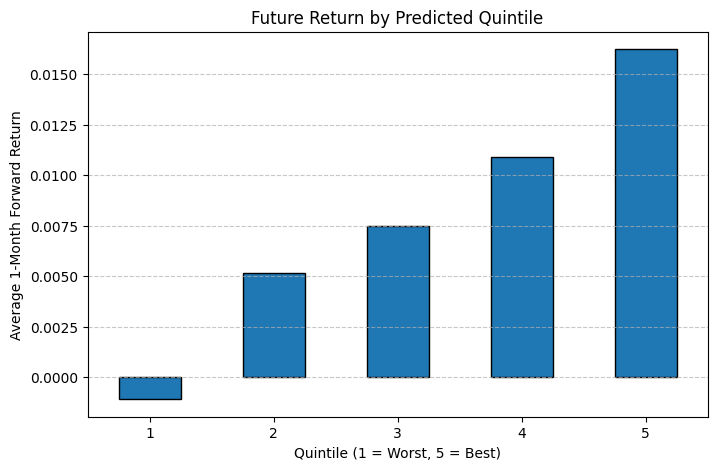

IC Mean : 0.0665   (target: > 0.05 | good: 0.05–0.08 | ref: XGBRanker NDCG baseline ~0.08, regression ~0.044 [LambdaRankIC, Lin et al. 2025])
IC Std  : 0.1626   (target: < 0.12 | lower = more stable signal; typical range 0.08–0.15 for 300-stock universe)
IC IR   : 0.4090   (target: > 0.3  | good: 0.3–0.5 | strong: > 0.5 [practitioner consensus]; small universe inflates Std so > 0.3 is realistic here)


In [6]:
print('--- Predictive Power (Alpha Generation) ---')
ev.compute_top_quantile_win_rate(test_df=honest_test_df_basic, top_quantile=0.2, ret_col='next_1m_ret')
ev.plot_return_by_predicted_quintile(test_df=honest_test_df_basic)
model_ic_basic = ev.compute_model_ic(honest_test_df_basic)

## 3.5 Run 2 — Alphaforge (GP Alpha Mining + LSTM Meta-Combiner)

Two additional alpha layers are added on top of the base feature set, both fit **per fold on training data only** — no look-ahead leakage:

**GP Alpha Mining (`gplearn`)** — A `SymbolicTransformer` uses genetic programming to evolve mathematical expressions (e.g. `log(volatility_1m) / log_ret_3m`) that correlate with forward returns. Each fold produces up to 10 new synthetic signals (`GP_Alpha_0..9`).

**LSTM Meta-Combiner (`DynamicAlphaCombiner`)** — A small LSTM-Attention network that learns to blend the WorldQuant alpha pool into a single meta-signal (`Mega_Alpha`), capturing temporal dependencies across signals.

In [7]:
honest_test_df_alphaforge = md.walk_forward_cv(
    df=df,
    model_params=BASE_MODEL_PARAMS,
    features=candidate_features,
    model='alphaforge',
    use_gp=True,
    liquidity_filter=False,
    **WF_PARAMS
)

print(f'OOS rows generated: {len(honest_test_df_alphaforge)}')
print(f'Date range        : {honest_test_df_alphaforge["date"].min()} → {honest_test_df_alphaforge["date"].max()}')
honest_test_df_alphaforge.head()

🧬 Mining GP alpha factors (fit on initial window only)...
   ✅ 15 GP factors added.
🚀 Starting walk-forward fold loop...
Fold 1/15 [AlphaForge (Mega)] (2019-01): NDCG = 0.8578
Fold 2/15 [AlphaForge (Mega)] (2019-07): NDCG = 0.8548
Fold 3/15 [AlphaForge (Mega)] (2020-01): NDCG = 0.8669
Fold 4/15 [AlphaForge (Mega)] (2020-07): NDCG = 0.8465
Fold 5/15 [AlphaForge (Mega)] (2021-01): NDCG = 0.8592
Fold 6/15 [AlphaForge (Mega)] (2021-07): NDCG = 0.8792
Fold 7/15 [AlphaForge (Mega)] (2022-01): NDCG = 0.8595
Fold 8/15 [AlphaForge (Mega)] (2022-07): NDCG = 0.8675
Fold 9/15 [AlphaForge (Mega)] (2023-01): NDCG = 0.8738
Fold 10/15 [AlphaForge (Mega)] (2023-07): NDCG = 0.8649
Fold 11/15 [AlphaForge (Mega)] (2024-01): NDCG = 0.8655
Fold 12/15 [AlphaForge (Mega)] (2024-07): NDCG = 0.8711
Fold 13/15 [AlphaForge (Mega)] (2025-01): NDCG = 0.8764
Fold 14/15 [AlphaForge (Mega)] (2025-07): NDCG = 0.8746
Fold 15/15 [AlphaForge (Mega)] (2026-01): NDCG = 0.8678

✅ Walk-forward CV complete.
OOS rows generated:

,date,open,high,low,close,volume,Symbol,log_ret_1w,log_ret_1m,log_ret_3m,...,GP_Alpha_8,GP_Alpha_9,GP_Alpha_10,GP_Alpha_11,GP_Alpha_12,GP_Alpha_13,GP_Alpha_14,Mega_Alpha,pred_score,pred_quintile
495,2019-01-07,10.93,10.96,10.77,10.85,1104290,AAA,-0.017536,-0.087322,-0.176251,...,-0.315117,-0.307074,-0.363680,-0.373589,-0.426720,-0.609367,-0.498734,-0.040627,-0.040627,1
2764,2019-01-07,9.02,9.02,8.51,8.51,90,AAM,-0.015521,0.038729,0.012367,...,-0.084907,-0.120825,-0.077938,-0.102229,-0.110709,-0.355853,-0.331164,0.000355,0.000355,4
4968,2019-01-07,24.41,25.45,24.10,24.73,2460,ABT,-0.039964,-0.147826,-0.099923,...,-0.148226,-0.148538,-0.183646,-0.218850,-0.275086,-0.665851,-0.569211,0.012689,0.012689,5
6958,2019-01-07,6.41,6.41,6.33,6.37,1305819,ACB,-0.014229,-0.094151,-0.172185,...,0.066782,0.084427,0.041260,0.040932,0.015242,-0.069434,-0.029228,-0.036423,-0.036423,1
9237,2019-01-07,5.06,5.51,5.06,5.51,180,ACC,-0.061280,0.013097,0.077258,...,1.186747,0.929264,0.925425,1.153999,1.039669,0.417279,0.447155,0.028355,0.028355,5


### Signal Quality — Alphaforge

--- Predictive Power (Alpha Generation) ---
--- Backtest Results (Top 20% Picks) ---
Top Picks Win Rate:   54.42%
Market Baseline:      51.16%
Excess Win Rate:      +3.26%


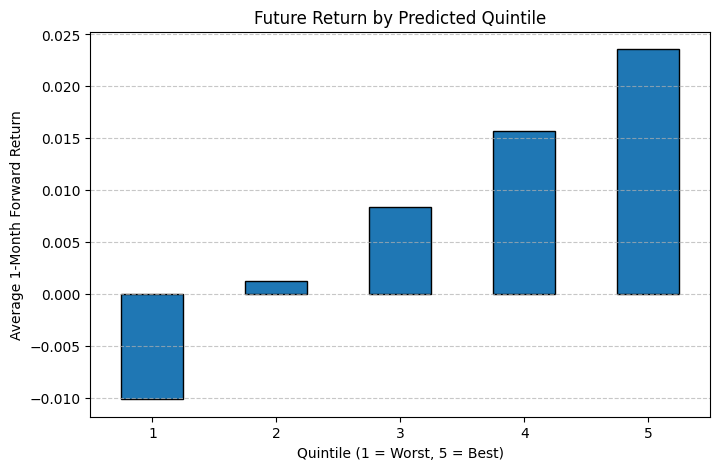

IC Mean : 0.1145   (target: > 0.05 | good: 0.05–0.08 | ref: XGBRanker NDCG baseline ~0.08, regression ~0.044 [LambdaRankIC, Lin et al. 2025])
IC Std  : 0.1788   (target: < 0.12 | lower = more stable signal; typical range 0.08–0.15 for 300-stock universe)
IC IR   : 0.6401   (target: > 0.3  | good: 0.3–0.5 | strong: > 0.5 [practitioner consensus]; small universe inflates Std so > 0.3 is realistic here)


In [8]:
print('--- Predictive Power (Alpha Generation) ---')
ev.compute_top_quantile_win_rate(test_df=honest_test_df_alphaforge, top_quantile=0.2, ret_col='next_1m_ret')
ev.plot_return_by_predicted_quintile(test_df=honest_test_df_alphaforge)
model_ic_alphaforge = ev.compute_model_ic(honest_test_df_alphaforge)

## 3.6 IC Comparison

Side-by-side signal quality summary. Note that IC here is computed across the **full universe** — this is the correct metric for ranking model quality, independent of how many stocks the portfolio ultimately selects.

In [9]:
ic_comparison = pd.DataFrame({
    'Basic':       model_ic_basic,
    'Alphaforge':  model_ic_alphaforge,
}).T

print(ic_comparison.to_string())

             ic_mean    ic_std     ic_ir                                                                                                                                                                                                                                                                                        daily_ic
Basic       0.066502  0.162588  0.409024  date
2019-01-07    0.069877
2019-01-08    0.032456
2019-01-09    0.069570
2019-01-10    0.079368
2019-01-11    0.103621
                ...   
2026-05-05    0.154181
2026-05-06    0.215699
2026-05-07    0.231856
2026-05-08    0.312739
2026-05-11    0.262737
Length: 1829, dtype: float64
Alphaforge  0.114472  0.178823  0.640143  date
2019-01-07   -0.063219
2019-01-08   -0.091050
2019-01-09   -0.015393
2019-01-10   -0.034536
2019-01-11   -0.083751
                ...   
2026-05-05    0.032014
2026-05-06    0.054706
2026-05-07    0.113928
2026-05-08    0.163866
2026-05-11    0.139452
Length: 1829, dtype: float64


## 3.7 Save OOS Predictions

In [10]:
honest_test_df_basic.to_parquet('/kaggle/working/honest_test_df_basic.parquet', index=False)
honest_test_df_alphaforge.to_parquet('/kaggle/working/honest_test_df_alphaforge.parquet', index=False)

print('Saved:')
print('  data/honest_test_df_basic.parquet')
print('  data/honest_test_df_alphaforge.parquet')

Saved:
  data/honest_test_df_basic.parquet
  data/honest_test_df_alphaforge.parquet


## Summary

| Model | IC Mean | IC IR | Notes |
|---|---|---|---|
| Basic | see above | see above | 24 hand-crafted features |
| Alphaforge | see above | see above | + GP alphas + LSTM meta-combiner |

Higher IC IR = more consistent ranking signal across time. A good IC does not guarantee high Sharpe — see notebook 04 for the full risk-adjusted picture.

**Next step →** `04_Backtesting_and_Evaluation.ipynb` — portfolio simulation, equity curves, and model comparison.